# Continuous Nonlinear Dynamics


(Partially adapted from Landau Chapter 15, *Continuous Nonlinear Dynamics*. Equation labels are kept the same for comparison if you have the textbook.)

In this module we will explore **continuous** systems where chaotic behavior emerges, using pendulums from classical mechanics as our main examples. Here we will use ODE solvers to explore chaos, as well as work with new concepts – like phase space – to display simple analysis graphs that underlie complex behaviors.

## 1.  Chaotic Pendulum

The plane pendulum is a classic subject for physics.
However, it has most often been studied assuming small angle
displacements. When the pendulum is driven and the
displacements get large, the motion becomes too complicated for analytic
solution. Your overall task for this module is to compute the motion of a driven pendulum
with large displacements, to ensure that your calculation is reliable
and sensitive, and then to search for the simplicity that may underlie
complexity.

What we call a *chaotic pendulum* is just a pendulum with friction and a
driving torque (see Figure below), but without the assumption of
small-deflection-angle. 

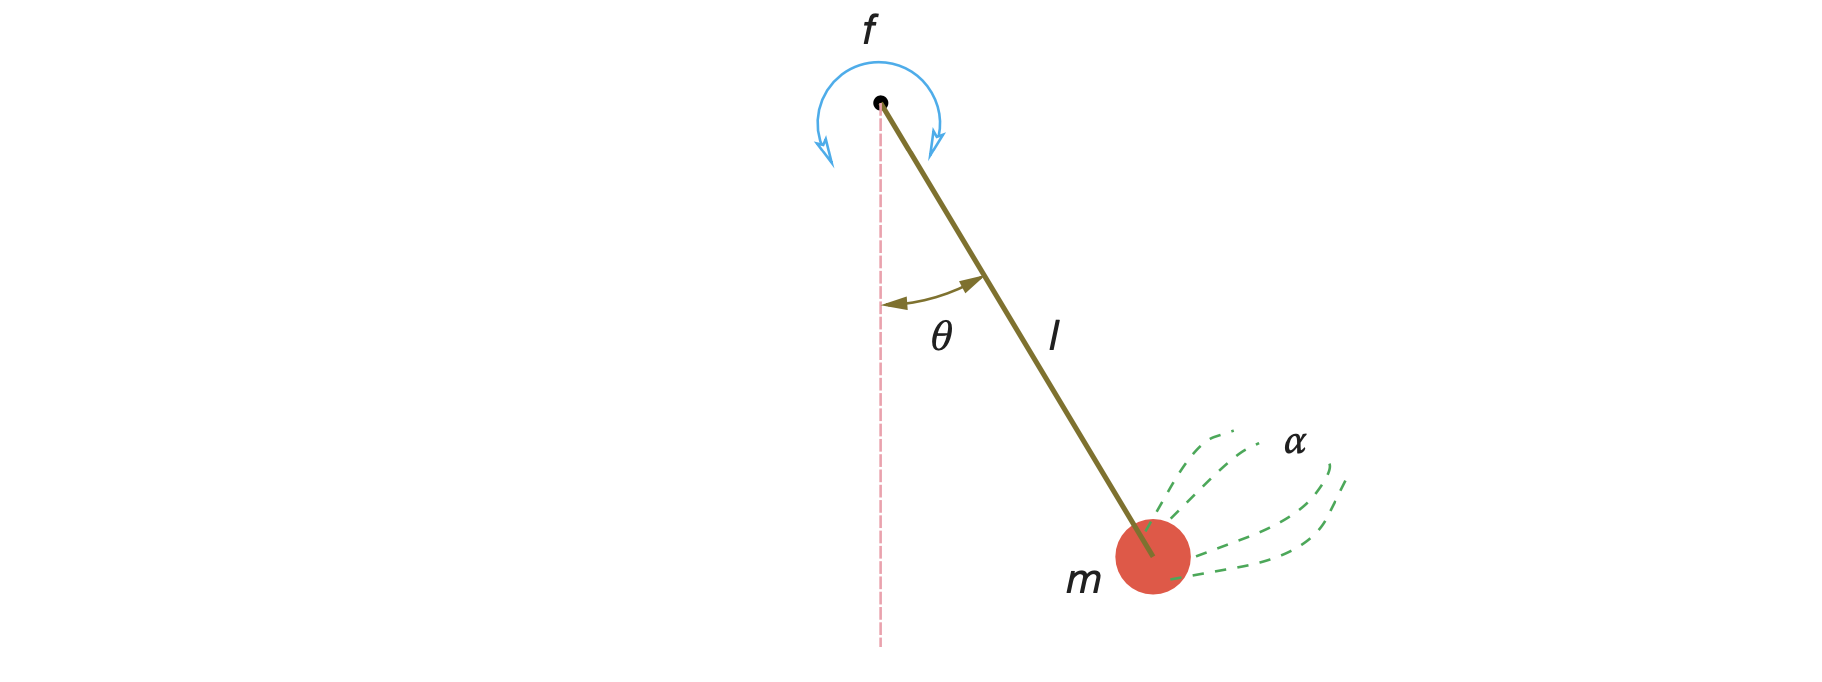

Newton’s laws of rotational motion tell us that
the sum of the gravitational torque $-
{mgl}\sin\theta$, the frictional torque $- {\beta}
\dot{\theta}$, and the external torque ${\tau_{0}}\cos
 \Omega t$ equals the moment of inertia of the pendulum times its
angular acceleration:

$$\begin{align}\tag*{15.1}
I \frac{d^{2}\theta}{dt^{2}}& = - {mgl} \sin\theta - {\beta} \frac{d\theta} {dt} +
{\tau_{0}} \cos\Omega t,\end{align}$$


where $I$ is the moment of inertia of the pendulum, and $\Omega$ is the angular frequency of the external torque. This equation can be simplified into


$$\begin{align}\frac{d^{2}\theta}{dt^{2}}  &  =
-\omega_{0}^{2} \sin \theta -\alpha \frac{d\theta}{dt} + f\cos\Omega
t,\tag*{15.2}\\
\mbox{where}\quad \omega_{0}^{2} &  =  \frac{mgl}{I},\quad \alpha =
\frac{\beta}{I}, \quad f =\frac{\tau_0}{I}.\tag*{15.3}\end{align}$$

Equation (15.2) is a second-order time-dependent nonlinear differential
equation. Its nonlinearity arises from the $\sin\theta$ term in the gravitational torque, as opposed to
a linear $\theta$ term in small-angle approximations. The parameter
$\omega_{0}$ is the natural frequency of the system arising from the
restoring torque, $\alpha$ is a measure of the strength of friction, and
$f$ is a measure of the strength of the driving torque. Broken down into two first-order ODEs, we have:

$$\begin{align}
\tag*{15.4}
\frac{d\theta}{dt}  & =   \omega, \text{ the angular velocity of the pendulum,}\\
\frac{d\omega}{dt} & =  - \omega_{0}^{2} \sin \theta - \alpha
\omega + f\cos\Omega t , \tag*{15.5} \end{align}$$

## 1.1  Free Pendulum Oscillations

If we ignore friction and external torques, we get a **realistic free pendulum**. Newton’s law (15.2) takes the simple, yet still nonlinear, form $$\tag*{15.6}
\frac{d^{2}\theta}{dt^{2}} = -\omega_{0}^{2} \sin \theta$$

If the displacements are small, we can approximate $\sin \theta$ by
$\theta$ and obtain the linear equation of simple harmonic motion with
frequency $\omega_0$:

$$\tag*{15.7}
\frac{d^{2}\theta}{dt^{2}} \simeq -\omega_0^2 \theta
$$

with the harmonic solution
$$ \theta(t) = \theta_{0} \sin(\omega_{0} t
+ \phi).$$

Without the small-angle approximation, we can still expect solutions of a **realistic free pendulum** (15.6) to be periodic, but with a frequency $\omega \simeq
\omega_0$ only for small oscillations. Furthermore, because the
restoring torque, $mgl\sin\theta \simeq mgl (\theta - \theta^3/3)$, is
less than the $mgl\theta$ assumed in a harmonic oscillator, **realistic
pendulums swing slower** (have longer periods) as their angular
displacements are made larger. This will be verified soon.

The analytic solution to the realistic pendulum is a textbook problem involving elliptical integrals. Here we will opt to find a numerical solution.

## 1.2  Implementing the Free Pendulum

<div class="span alert alert-success">

Here we will consider a free pendulum and use our Euler or Runge-Kutta-2nd-order ODE solver to solve (15.6). Later on in this module we will use the code you develop here as a basis for solving the equations of motion of a driven pendulum (15.2).


1.  Set up your program for a **realistic free pendulum**. First test your program for small angles, and verify that your solution is approximately harmonic with frequency $\omega_{0}$ by comparing your numerical solution with the analytical solution under a small-angle approximation. For simplicity we'll start with the natural frequency being $\omega_0 = 1$.

<div class="span alert alert-success">
Gradually increase your $\theta(0)$ while keeping $\omega(0)=\dot{\theta}(0)= 0$, i.e. you are simulating releasing the pendulum from larger initial angles. Describe any nonlinear effects you see in the oscillations. Does your numerical solution still agree with the analytical solution? What happens if you release the pendulum at the very top $\theta(0)=\pi$?

<div class="span alert alert-success">
Set the initial conditions in a way such that the motion changes from oscillatory to rotational (i.e. the pendulum swings over the top).

## 2  Visualization: Phase Space Orbits<a id="15.2"></a>

So far we've been plotting only $\theta(t)$. To prepare ourselves for analyzing more complex behaviors, we'll introduce the concept of phase space here, where we can visualize both $\theta(t)$ and $\dot{\theta}(t)$ (or equivalently, $\omega(t)$).

Consider a general solution to an equation of motion where the position
$x(t)$ and the velocity $v(t)$ are functions of time. Often behaviors
that appear complicated as functions of time appear simpler when viewed
in an abstract space called *phase space*, where the ordinate is the
velocity $v(t)$ and the abscissa is the position $x(t)$ (Figure 15.3).
As we see from the phase space figures, the solutions form geometric
objects that are easy to recognize.

In **Figure 15.3** below, we demonstrate two potentials along with the phase space trajectories of particles moving in these potentials. The different orbits below the potentials correspond to different energies, as
indicated by the limits of maximum displacements within the potentials (vertical dashed
lines). 

**Figure 15.3** left panel shows that a repulsive potential leads to open orbits characteristic of
nonperiodic motion. The trajectories cross at the hyperbolic point in the middle,
an unstable equilibrium point. 

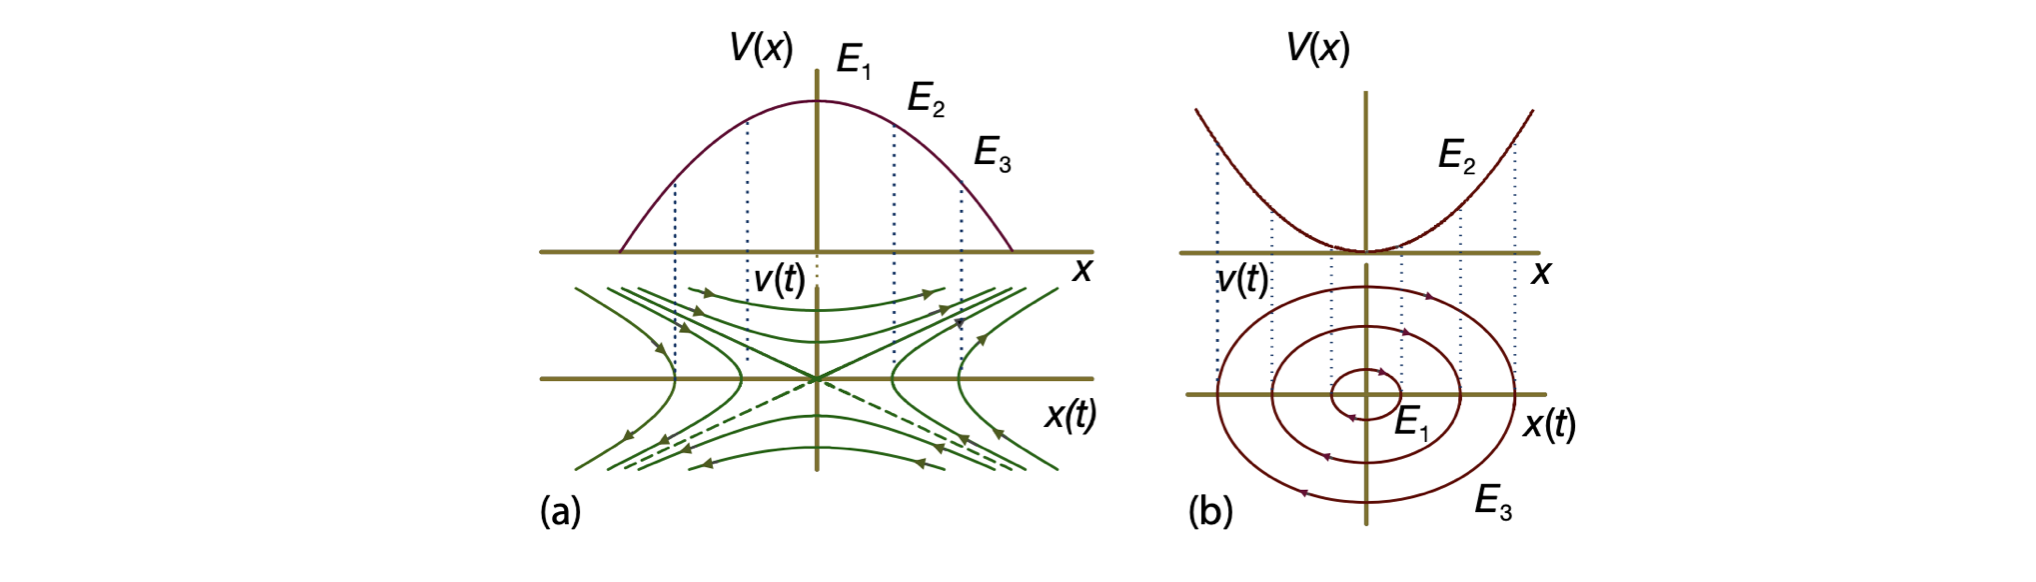

**Figure 15.3** right panel shows that a free harmonic oscillator leads to
symmetric ellipses; the closed orbits indicate periodic behavior, and the symmetric trajectories indicate a symmetric potential. The position and velocity of a free harmonic oscillator are given by the
trigonometric functions

$$\tag*{15.11} x(t)= A \sin(\omega t),\quad v(t) = \frac{dx}{dt} = \omega A
\cos(\omega t).$$

When substituted into the total energy, we obtain two important results:

$$\begin{align}
\tag*{15.12}
E & =  {\rm KE} + {\rm PE} = \left(\frac{1}{2} m\right) v^{2} +
\left(\frac{1}{2} m\omega^{2}\right) x^{2}\\
& =  \frac{m \omega^{2} A^{2}}{2} \cos^{2}(\omega t) +
\frac{m\omega^{2} A^{2}}{2} \sin^{2}(\omega t) = \frac{1}{2}
m\omega^{2}A^{2}.\tag*{15.13}\end{align}$$

The first equation, being that of an ellipse, proves that the harmonic
oscillator follows closed elliptical orbits in phase space, with the
size of the ellipse increasing with the system’s energy. The second
equation proves that the total energy is a constant of the motion.
Different initial conditions having the same energy start at different
places on the same ellipse and traverse the same orbits.

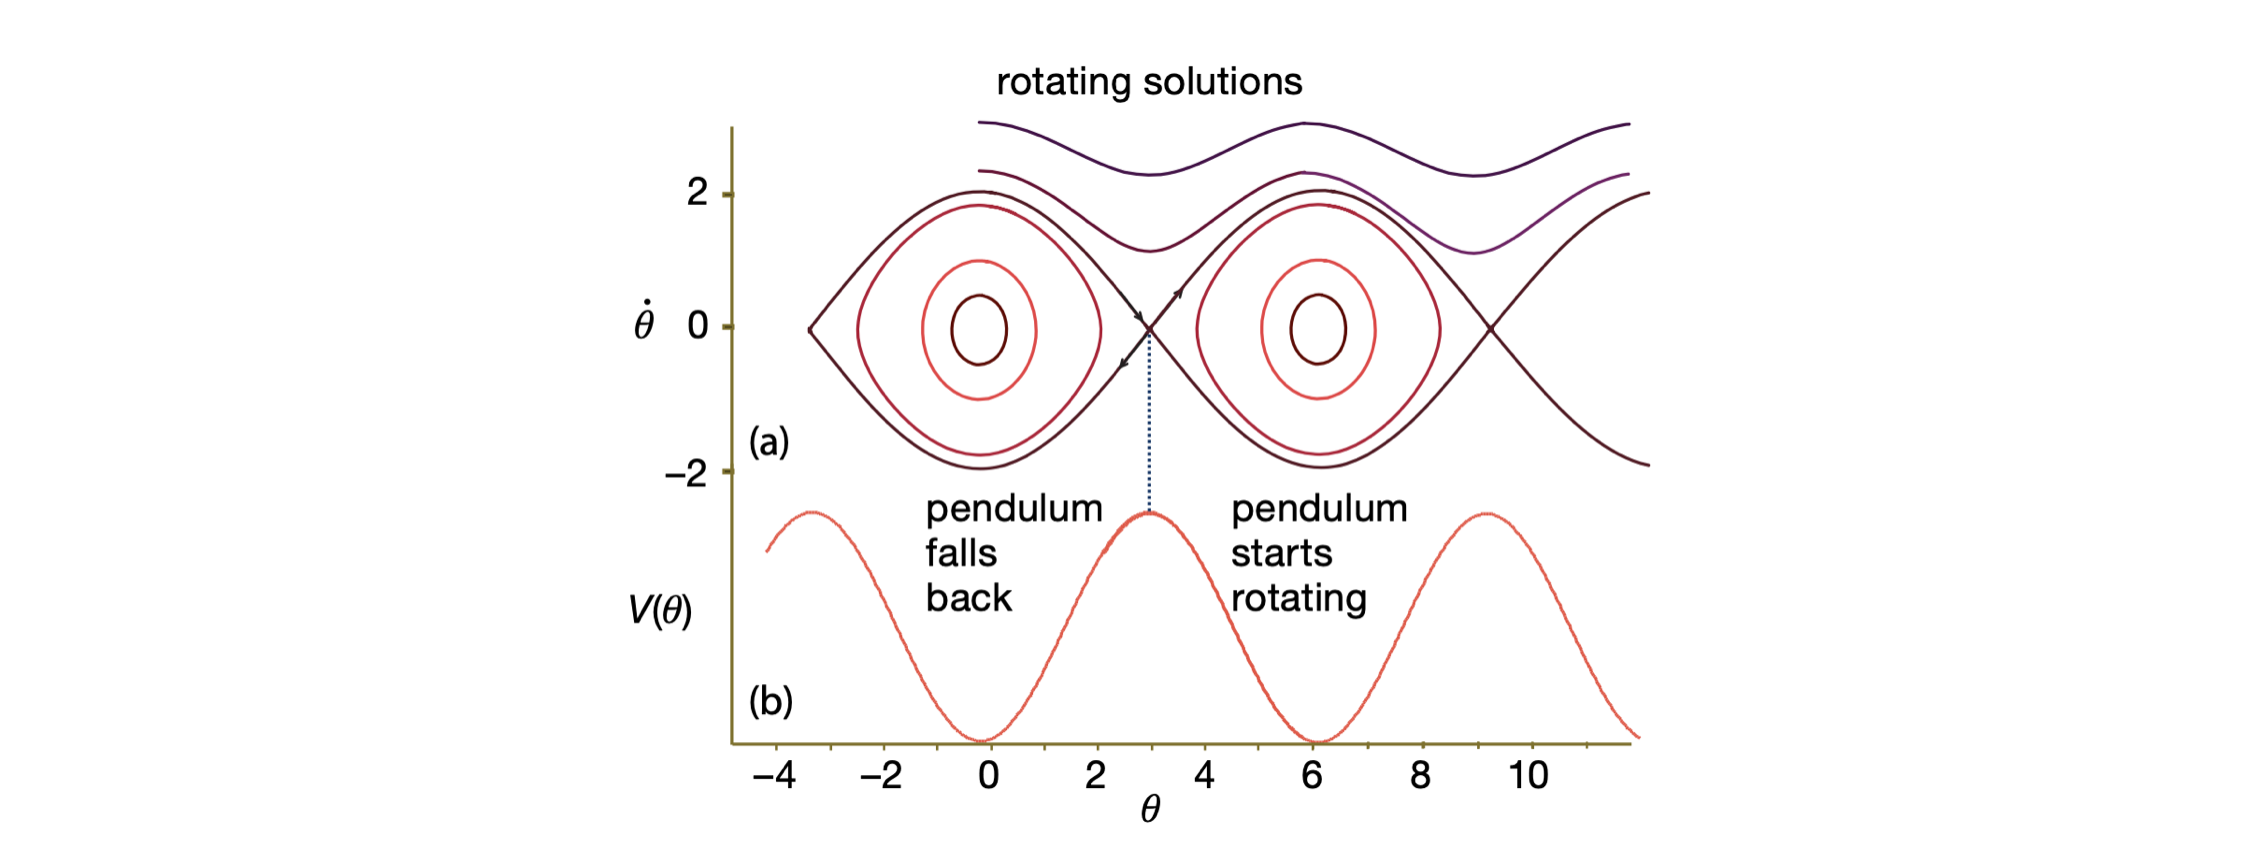

<div class="span alert alert-success">

1. Make phase space trajectory plots for your numerical solutions of $ \theta(t) $ and $ \dot{\theta}(t)=\omega(t) $ for the realistic free pendulum. An expected outcome shown in the upper part of the figure above plotting $\theta $ against $ \dot{\theta}$: following this figure, you should vary initial conditions to generate at least one of the following behaviors.
    
-   Closed trajectories describe periodic oscillations \[the same
    $(x,v)$ occur again and again\], with a clockwise motion arising
    from the restoring torque.

    
-   Open orbits correspond to running motion (a
    pendulum rotating like a propeller).

    
-   A special solution exist between the closed and open trajectories: the connected closed orbits with pointy ends. This is called the **separatrix**, where motion is indeterminate, as the pendulum may balance, or move either left or right from the top.

    
(Notice that different orbits never cross, because solutions for different initial conditions are unique.)

In [ ]:

plt.xlabel(r'$\Theta$ (radians)')
plt.ylabel(r'$\dot\Theta$ (rad/s)')
plt.title('Phase Space Trajectories')
plt.xlim(-np.pi, 3*np.pi)
plt.ylim(-3, 3)
plt.show();

<div class="span alert alert-success">
After producing the whole plot, identify regions of phase space where the potential is repulsive and leads to shapes like in Figure 15.3 left panel, and where the potential is attractive and leads to shapes like in figure 15.3 right panel.

## 3  Chaotic Behavior of Driven Pendulum

With the preparation above, we are now ready to model a driven pendulum with friction, where **period doubling** and **chaotic behavior** can emerge. Returning to Equations 15.4 and 15.5, the two coupled first-order ODEs we already encountered earlier,

$$\begin{align}
\tag*{15.4}
\frac{d\theta}{dt}  & =   \omega, \text{ the angular velocity of the pendulum,}\\
\frac{d\omega}{dt} & =  - \omega_{0}^{2} \sin \theta - \alpha
\omega + f\cos\Omega t , \tag*{15.5} \end{align}$$

we recall that $\omega_{0}$ is the natural frequency of the system arising from the
restoring torque, $\alpha$ is a measure of the strength of friction, $\Omega$ is the angular frequency of the driving torque, and $f$ is a measure of the strength of the driving torque.

In the following, we will take $\alpha$ = 0.75, $\omega_0$=1.5, and $\Omega$ = 1, so that the period of the driving torque is $2\pi$. We will be mostly varying $f$ to monitor the pendulum's behavior, starting with $f$=2.

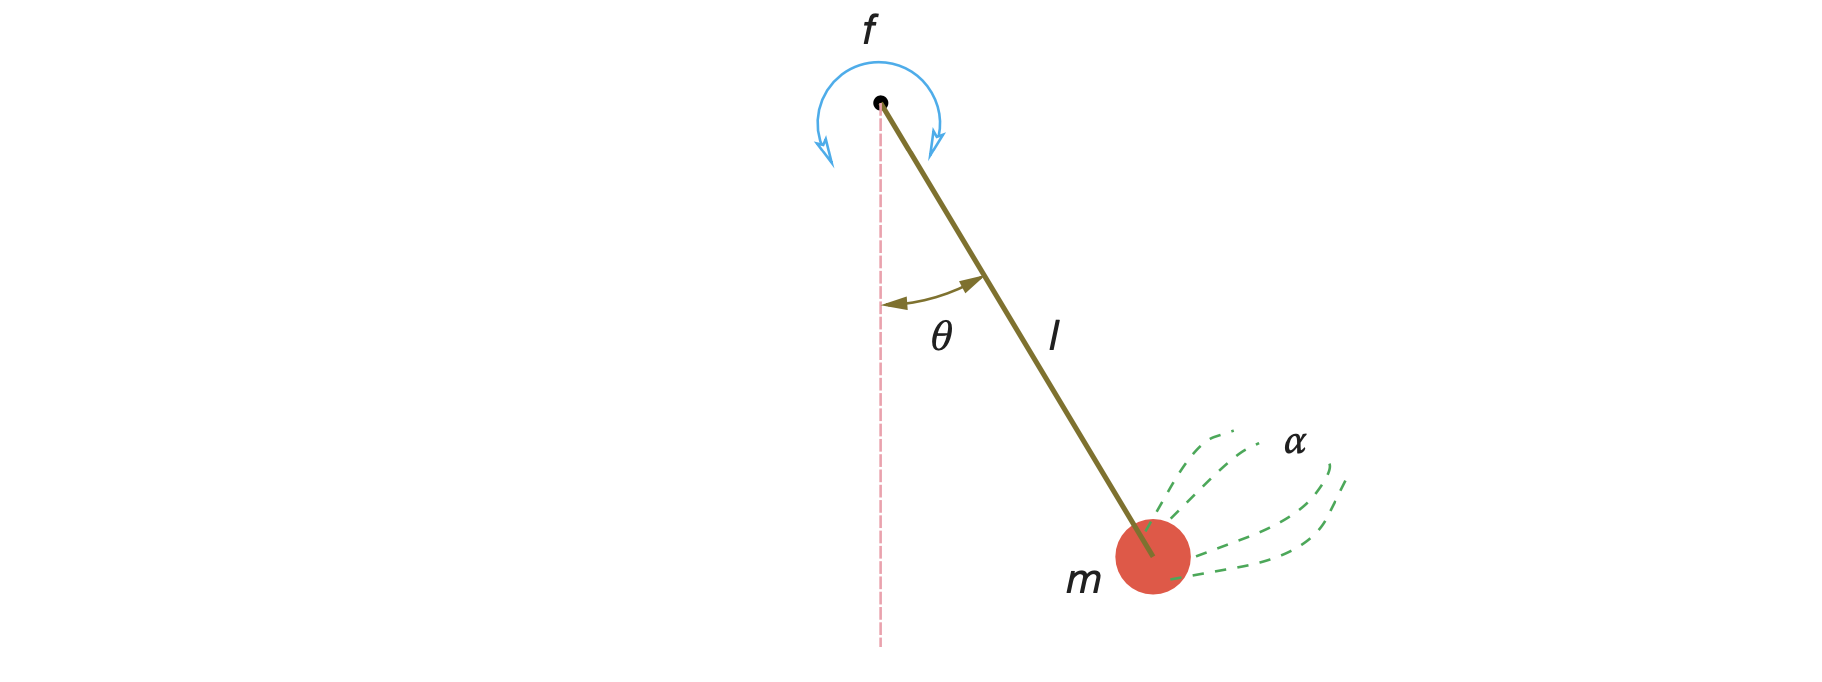


<div class="span alert alert-success">

1. Based on your simple pendulum code, implement the driven pendulum with friction with the parameters defined above and f=2. Generate an angle versus time plot so you can visualize the oscillations.
    
    
2. Verify the following physical regimes of the driven pendulum:

- For f=2.025, the pendulum settles into a simple oscillation.

    
- For f=2.385, a long **transient** state is seen before settling into a simple oscillation.

    
- For f=2.4075, the period of the oscillation doubles into a **two cycle**, reminiscent of the **Period Doubling** in bug population dynamics we encountered in Module 1. In other words, the system undergoes a first **bifurcation**.

    
- For f=2.4345, the system undergoes another period doubling into a **four cycle**. Notice that we are increasing f more and more slowly, similar to how we increased $\mu$ in the bug population dynamics models approaching chaotic behavior.

    
- Further period doublings become very hard to see in these plots. For f=2.43585, the **eight cycle** begins, but you probably can't resolve it clearly here. We'll return to this in the phase space plots in the next cell.
    

- Further increasing f pushes the system into a chaotic regime. For example, for f=3.375, the angle versus time plot appears erratic.


</div>

Some example outputs for the cases discussed above are given below.
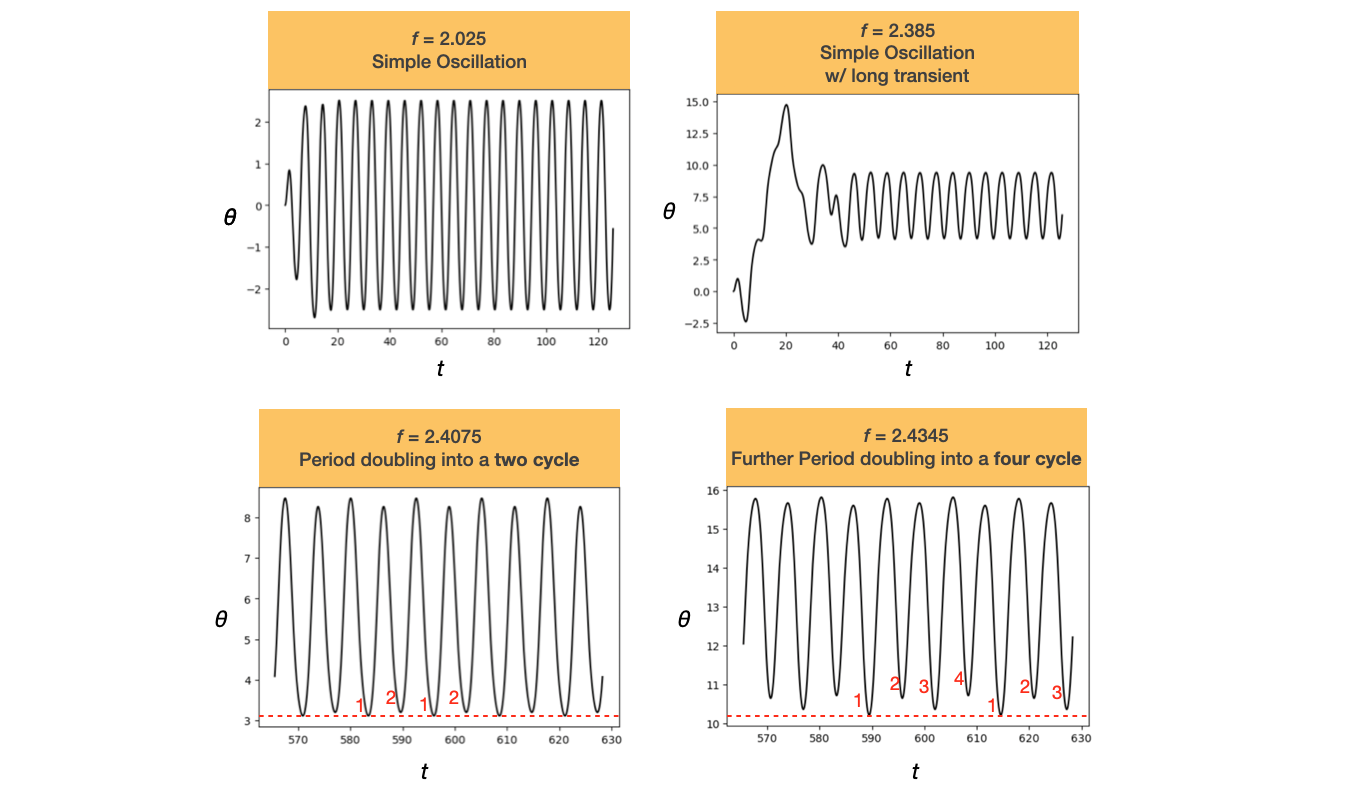

In [ ]:
w0 = 1.5
alpha = 0.75
Omega = 1.0
N = 1500                      
dt = 2*np.pi / Omega / N      

def diffeq_driven(y, t, f):
    theta, omega = y
    ydot = np.array([omega, -w0**2*np.sin(theta) - alpha*omega + f*np.cos(Omega*t)])
    return ydot

def simulate(f, n_periods, theta_init=0.0, omega_init=0.0):
    n_steps = n_periods * N
    t_range = np.arange(n_steps + 1) * dt
    theta = np.empty(n_steps + 1)
    omega = np.empty(n_steps + 1)
    y = np.array([theta_init, omega_init])
    theta[0], omega[0] = y
    for i in range(n_steps):
        y = move_RK2(diffeq_driven, y, t_range[i], dt, f)
        theta[i+1], omega[i+1] = y
    return t_range, theta, omega

def plot_theta(t, theta, f, tmin=None, tmax=None):
    tmin = t[0] if tmin is None else tmin
    tmax = t[-1] if tmax is None else tmax
    window = (t >= tmin) & (t <= tmax)
    plt.figure(figsize=(6,4))
    plt.plot(t[window], theta[window])
    plt.xlabel('Time')
    plt.ylabel(r'$\Theta$')
    plt.title(f'Pendulum Motion f = {f}')
    plt.show()

f = 2.025
t, theta, omega = simulate(f, n_periods=240)
plot_theta(t, theta, f, 0, 120)

In [ ]:
f = 2.385
t, theta, omega = simulate(f, n_periods=240)
plot_theta(t, theta, f, 0, 300)

In [ ]:
f = 2.4075
t, theta, omega = simulate(f, n_periods=240)
plot_theta(t, theta, f, 550, 630)

In [ ]:
f = 2.4345
t, theta, omega = simulate(f, n_periods=240)
plot_theta(t, theta, f, 550, 630)

In [ ]:
f = 3.375
t, theta, omega = simulate(f, n_periods=240)
plot_theta(t, theta, f)

To better visualize the above process of **period doubling** and eventually moving into a **chaotic** regime, next we will plot your solutions of $\theta$ and $\dot\theta$ in **phase space**. Similar to the angle versus time plots, the phase space trajectory plots will quickly become complex as we approach chaos as well. To address that, we will introduce Poincaré sections as a tool to simplify the visualization.

<div class="span alert alert-success">   

1. Based on phase space trajectory plots you worked out earlier, implement similar plots here for $\theta$ and $\dot\theta$, for the first case discussed in the cell above where f=2.025. Use the modulo operator in python (%) to restrict all angles within $-\pi$ and $\pi$. You should see a closed shape.

    

2. **Poincaré sections.** Since we know that the period of the driving torque is $2\pi$, instead of plotting the entire trajectory of $\theta$ and $\dot\theta$, we can plot them at intervals of $2\pi$. That is, we will still solve for $\theta$ and $\dot\theta$ with our usual timestep dt (which should be small), but we only plot the values at $t=0, t=2\pi, t=4\pi$ and so on. *Tip:* choose $dt = 2\pi/(\Omega N)$ with an integer $N$, so that every drive period is exactly $N$ steps and the Poincaré points are simply every $N$-th point of the solution. Implement this using red dots and overlay this plot onto the full phase space trajectory, still for the case of f=2.025.
    

3. Make similar plots for all cases of f discussed in the cell above. Some example outputs are given below.
    
</div>


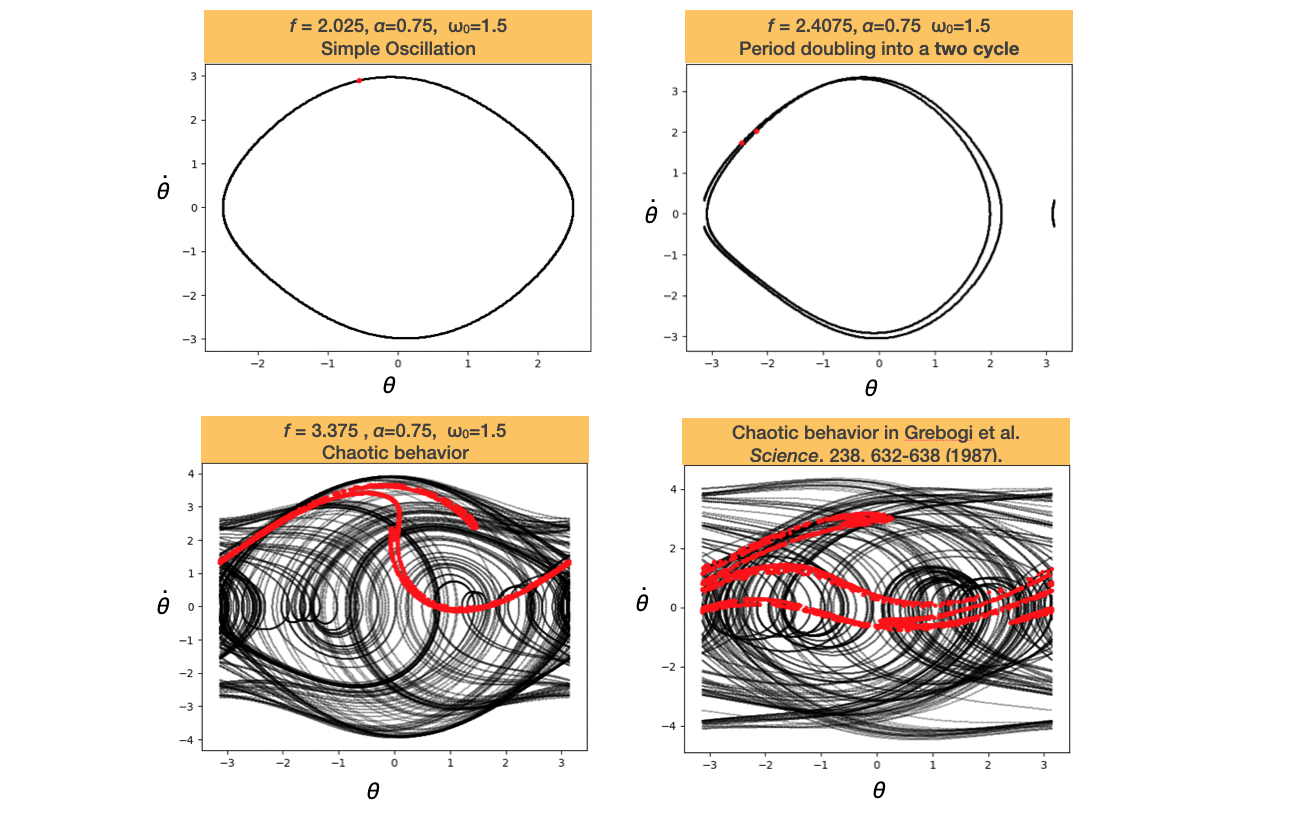

<div class="span alert alert-success">   
1. Phase space trajectories

<div class="span alert alert-success">   
2-3.  Poincaré sections